In [1]:
import sys
print(sys.executable)

C:\Users\swati\Supply Chain Analysis using Python\myenv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

In [4]:
!pip install scipy

In [5]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [6]:
import sys
print(sys.executable)

C:\Users\swati\Supply Chain Analysis using Python\myenv\Scripts\python.exe


In [7]:
import sys
!{sys.executable} -m pip install pandas

'C:\Users\swati\Supply' is not recognized as an internal or external command,
operable program or batch file.


In [8]:
import sys
!"{sys.executable}" -m pip install pandas

In [9]:
import pandas as pd
print(pd.__version__)

3.0.1


In [10]:
import sys
!"{sys.executable}" -m pip install numpy matplotlib seaborn scipy scikit-learn openpyxl

In [11]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [12]:
import pandas as pd

sales = pd.read_csv("./data/transactions_100.csv", sep=",", index_col=0)

print("Number of Transactions: {:,}".format(len(sales)))

sales.head()

Number of Transactions: 686,500


,SKU,ITEM,FAMILY,CATEGORY,STORE,DAY,QTY,TO
808,REF-808,ITEM-809,FAMILY-4,FOODS,STORE-1,1,3,6.00
809,REF-809,ITEM-810,FAMILY-4,FOODS,STORE-1,1,0,0.00
810,REF-810,ITEM-811,FAMILY-4,FOODS,STORE-1,1,0,0.00
811,REF-811,ITEM-812,FAMILY-4,FOODS,STORE-1,1,3,8.82
812,REF-812,ITEM-813,FAMILY-4,FOODS,STORE-1,1,0,0.00


In [13]:
metric_col = 'QTY'
GRBY = ['ITEM', 'FAMILY']

# Pivot Table by ITEM
df_abc = pd.pivot_table(
    sales,
    index=GRBY,
    values=metric_col,
    columns='DAY',
    aggfunc='sum'
).fillna(0)
print("Number of Items: {:,}".format(len(df_abc)))
df_abc.head()

Number of Items: 812


,DAY,1,2,3,4,5,6,7,8,9,10,...,91,92,93,94,95,96,97,98,99,100
ITEM,FAMILY,,,,,,,,,,,,,,,,,,,,,
ITEM-1000,FAMILY-5,2,4,5,1,0,5,1,1,7,3,...,1,5,7,3,8,3,0,2,4,6
ITEM-1001,FAMILY-5,8,14,9,6,12,15,17,28,23,19,...,9,16,11,12,7,5,16,10,8,4
ITEM-1002,FAMILY-5,7,27,14,12,11,18,6,30,23,21,...,19,5,13,13,17,9,5,10,10,16
ITEM-1003,FAMILY-5,5,4,5,1,7,5,9,5,5,4,...,5,8,5,6,14,5,9,3,8,6
ITEM-1004,FAMILY-5,22,16,14,14,16,10,11,17,12,16,...,3,17,9,11,8,6,6,7,10,8


In [14]:
LIST_DAYS = df_abc.columns.tolist()
# Total Sales
df_abc[f"{metric_col}"] = df_abc[LIST_DAYS].sum(axis=1) 
# Sales Stats
df_abc["MEAN"] = df_abc[LIST_DAYS].mean(axis=1)
df_abc["STD"] = df_abc[LIST_DAYS].std(axis=1)
df_abc["MAX"] = df_abc[LIST_DAYS].max(axis=1)
df_abc["DAYS_ACTIVE"] = (df_abc[LIST_DAYS]>0).sum(axis=1)
#Filter out the items w/o sales
df_abc = df_abc[df_abc[f"{metric_col}"]>0]
# Coefficient of variation
df_abc["CV"] = df_abc["STD"]/ df_abc["MEAN"]
df_abc.head()

,DAY,1,2,3,4,5,6,7,8,9,10,...,97,98,99,100,QTY,MEAN,STD,MAX,DAYS_ACTIVE,CV
ITEM,FAMILY,,,,,,,,,,,,,,,,,,,,,
ITEM-1000,FAMILY-5,2,4,5,1,0,5,1,1,7,3,...,0,2,4,6,331,3.31,2.227899,12,94,0.673081
ITEM-1001,FAMILY-5,8,14,9,6,12,15,17,28,23,19,...,16,10,8,4,1193,11.93,5.525432,28,100,0.463154
ITEM-1002,FAMILY-5,7,27,14,12,11,18,6,30,23,21,...,5,10,10,16,1340,13.40,6.410219,32,100,0.478375
ITEM-1003,FAMILY-5,5,4,5,1,7,5,9,5,5,4,...,9,3,8,6,643,6.43,3.913858,20,100,0.608687
ITEM-1004,FAMILY-5,22,16,14,14,16,10,11,17,12,16,...,6,7,10,8,1084,10.84,5.509808,34,99,0.508285


In [21]:
'''Pareto Calculation on metric_col'''
pareto = df_abc.drop(LIST_DAYS, axis=1).copy()
pareto[f"{metric_col}_%"] = (100* pareto[f"{metric_col}"] / pareto[f"{metric_col}"].sum())
pareto.sort_values(by=f"{metric_col}_%", ascending=False,inplace=True)
# cumulative Sum
pareto[f"{metric_col}_%_CS"] = pareto[f"{metric_col}_%"].cumsum()

#SKU Counts
n_sku = len(pareto)
pareto["SKU_ID"] = pd.Series(range(1, n_sku + 1), index=pareto.index)
pareto["SKU_%"] = (100 * pareto["SKU_ID"]/(n_sku + 1 ))

# ABC Segmentation
criterion_a = 20/100
criterion_b = 50/100
n_a = int(criterion_a * n_sku)
n_b = int(criterion_b * n_sku)
pareto["ABC"] = pareto["SKU_ID"].apply(lambda x: "A" if x <= n_a else ("B" if x <= n_b else "C"))


pareto.head()

,DAY,QTY,MEAN,STD,MAX,DAYS_ACTIVE,CV,QTY_%,QTY_%_CS,SKU_ID,SKU_%,ABC
ITEM,FAMILY,,,,,,,,,,,
ITEM-1451,FAMILY-8,48322,483.22,98.523502,713,100,0.203890,2.742242,2.742242,1,0.123001,A
ITEM-1452,FAMILY-8,33170,331.70,78.474019,572,100,0.236581,1.882376,4.624617,2,0.246002,A
ITEM-1433,FAMILY-8,29216,292.16,66.720390,438,100,0.228369,1.657989,6.282606,3,0.369004,A
ITEM-1274,FAMILY-7,26885,268.85,73.382542,481,100,0.272950,1.525706,7.808312,4,0.492005,A
ITEM-1504,FAMILY-9,21429,214.29,43.216695,353,100,0.201674,1.216082,9.024394,5,0.615006,A


In [22]:
pareto["ABC"].value_counts()


ABC
C    406
B    244
A    162
Name: count, dtype: int64

,DAY,QTY,MEAN,STD,MAX,DAYS_ACTIVE,CV,QTY_%,QTY_%_CS,SKU_ID,SKU_%,ABC
ITEM,FAMILY,,,,,,,,,,,
ITEM-1451,FAMILY-8,48322,483.22,98.523502,713,100,0.203890,2.742242,2.742242,1,0.123001,A
ITEM-1452,FAMILY-8,33170,331.70,78.474019,572,100,0.236581,1.882376,4.624617,2,0.246002,A
ITEM-1433,FAMILY-8,29216,292.16,66.720390,438,100,0.228369,1.657989,6.282606,3,0.369004,A
ITEM-1274,FAMILY-7,26885,268.85,73.382542,481,100,0.272950,1.525706,7.808312,4,0.492005,A
ITEM-1504,FAMILY-9,21429,214.29,43.216695,353,100,0.201674,1.216082,9.024394,5,0.615006,A
...,...,...,...,...,...,...,...,...,...,...,...,...
ITEM-1453,FAMILY-8,2810,28.10,11.555313,58,100,0.411221,0.159466,62.122255,158,19.434194,A
ITEM-1067,FAMILY-6,2792,27.92,8.655797,50,100,0.310021,0.158444,62.280699,159,19.557196,A
ITEM-859,FAMILY-4,2788,27.88,16.327630,145,100,0.585640,0.158217,62.438916,160,19.680197,A


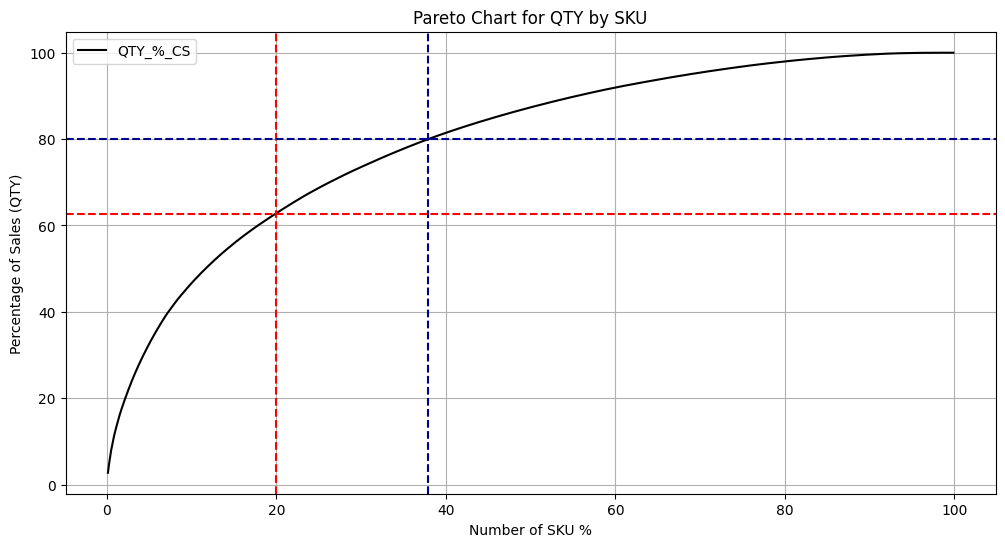

In [49]:
''' Pareto Chart by metric_col'''
ax = plt.gca()
pareto.plot( figsize = (12,6),x="SKU_%" , y=f"{metric_col}_%_CS",ax=ax, color = "black",grid=True )

# Cumulative % of SKUs to reach 80% of Sales
cumul_sku_80 = pareto[pareto[f"{metric_col}_%_CS"] <= 80]["SKU_%"].max()
# Cumulative % Sales of the top 20%
sales_sku20 = pareto[pareto[f"SKU_%"] <= 20][f"{metric_col}_%_CS"].max()


# Vertical Lines
ax.axvline(20, color = "red", linestyle= "--")
ax.axvline(cumul_sku_80, color = "darkblue", linestyle="--")

# Horizaontal Lines 
ax.axhline(80, color = "darkblue", linestyle= "--")
ax.axhline(sales_sku20, color = "red", linestyle= "--")


# Titles
plt.title(f"Pareto Chart for {metric_col} by SKU")
plt.xlabel("Number of SKU %")
plt.ylabel("Percentage of Sales (QTY)")
plt.show()

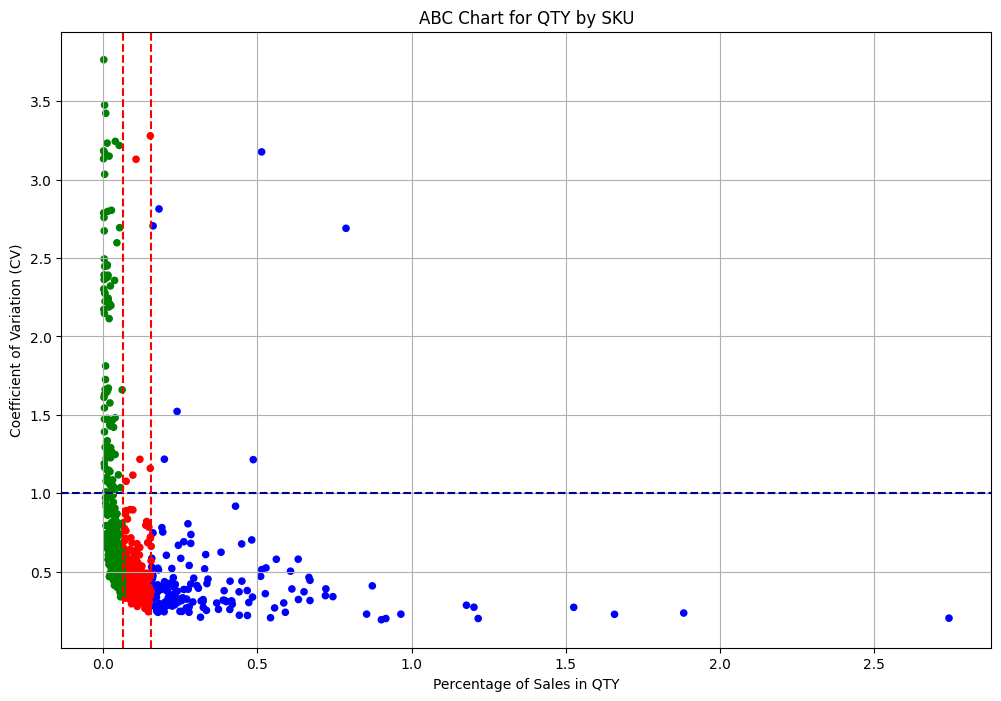

In [50]:
''' ABC Chart'''
max_CV = 4
color ={ "A" : "blue", "B" : "red",  "C" : "green"}
df_plot = pareto[pareto["CV"] <= max_CV].copy()
# Scatter Plot
ax = plt.gca()
df_plot.plot.scatter(figsize = (12,8),x=f"{metric_col}_%",y="CV" ,ax=ax, color=df_plot["ABC"].map(color), grid=True)

# Horizontal Line
ax.axhline(1, color="darkblue", linestyle="--")

# Vertical Line: Limit A
limit_a = pareto[pareto["ABC"] == "A"][f"{metric_col}_%"].min()
ax.axvline(limit_a, color = "red", linestyle= "--")
limit_b = pareto[pareto["ABC"] == "B"][f"{metric_col}_%"].min()
ax.axvline(limit_b, color = "red", linestyle= "--")


#Titles
plt.title(f"ABC Chart for {metric_col} by SKU")
plt.xlabel(f"Percentage of Sales in {metric_col}")
plt.ylabel("Coefficient of Variation (CV)")
plt.show()